In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data file -> matching label file
file_pairs = [
    ("fall_data_2.json", "fall_labels_2.json"),
    ("fall_data_3.json", "fall_labels_3.json"),
    ("fall_data_4.json", "fall_labels_4.json"),
    ("fall_data_5.json", "fall_labels_5.json")
]

parsed_cols = ['x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'SNS', 'target_count']

all_dfs = []

for data_file, label_file in file_pairs:
    print(f"Processing {data_file} with {label_file}...")

    # ----------------------------
    # Load radar data
    # ----------------------------
    with open(data_file, "r", encoding="utf-8") as f:
        fall_data = json.load(f)

    records = fall_data["data"]["result"]
    df = pd.DataFrame(records)

    # expand parsedData
    df[parsed_cols] = pd.DataFrame(df["parsedData"].tolist(), index=df.index)

    # keep only rows where parsedData is not all zeros
    df = df[df["parsedData"].apply(lambda x: any(v != 0 for v in x))].copy()

    # ensure createTime is string for matching
    df["createTime"] = df["createTime"].astype(str)

    # default label = 0
    df["fall_label"] = 0

    # ----------------------------
    # Load fall labels
    # ----------------------------
    with open(label_file, "r", encoding="utf-8") as f:
        label_data = json.load(f)

    falls = label_data["falls"]
    labels_df = pd.DataFrame(falls)

    # keep matching fields as string
    labels_df["timestamp_start"] = labels_df["timestamp_start"].astype(str)
    labels_df["radarUuid"] = labels_df["radarUuid"].astype(str)
    df["radarUuid"] = df["radarUuid"].astype(str)

    # create set of exact fall keys
    fall_keys = set(zip(labels_df["radarUuid"], labels_df["timestamp_start"]))

    # mark fall_label = 1 if (radarUuid, createTime) matches a labeled fall
    df["fall_label"] = df.apply(
        lambda row: 1 if (row["radarUuid"], row["createTime"]) in fall_keys else 0,
        axis=1
    )

    print("Rows kept:", df.shape[0])
    print("Falls labeled:", df["fall_label"].sum())

    all_dfs.append(df)
# combine all dataframes into one
fall_df = pd.concat(all_dfs, ignore_index=True)

print("\nCombined fall_df created successfully")
print("Shape:", fall_df.shape)
print("Total labeled falls:", fall_df["fall_label"].sum())
print(fall_df.head())

Processing fall_data_2.json with fall_labels_2.json...
Rows kept: 1085
Falls labeled: 18
Processing fall_data_3.json with fall_labels_3.json...
Rows kept: 1062
Falls labeled: 20
Processing fall_data_4.json with fall_labels_4.json...
Rows kept: 904
Falls labeled: 17
Processing fall_data_5.json with fall_labels_5.json...
Rows kept: 1102
Falls labeled: 20

Combined fall_df created successfully
Shape: (4153, 14)
Total labeled falls: 75
                    radarUuid      createTime  \
0  12E8FE50000400192600000005  20260314085100   
1  12E8FE50000400192600000005  20260314085104   
2  12E8FE50000400192600000005  20260314085107   
3  12E8FE50000400192600000005  20260314085112   
4  12E8FE50000400192600000005  20260314085117   

                                           data  dataType  \
0  4HiL4BLUNE4Cq+KeOa3wUaWZf8Cp7kdyNMbKS/AswOQ=         6   
1  8+WjQ0wX0DDLyKYRxyR+UNxMDJGhO2PC0sTO1Pnh3wk=         6   
2  JQKWM+iaTVh0rue8tpAIVWONsFyu1rBTd9v4tarsTMs=         6   
3  FAJsvDBKc8asR1TfIy81cf

In [2]:
radar_map = {
    '12E8FE50000400192600000001': 'Bedroom',
    '12E8FE50000400192600000002': 'Kitchen',
    '12E8FE50000400192600000003': 'Living Room',
    '12E8FE50000400192600000004': 'Office',
    '12E8FE50000400192600000005': 'Sunroom',
    '12E8FE50000400192600000006': 'Hallway'
}

fall_df['room'] = fall_df['radarUuid'].map(radar_map)

print(fall_df[['radarUuid', 'room']].drop_duplicates().sort_values('radarUuid'))

                      radarUuid         room
175  12E8FE50000400192600000001      Bedroom
76   12E8FE50000400192600000002      Kitchen
407  12E8FE50000400192600000003  Living Room
108  12E8FE50000400192600000004       Office
0    12E8FE50000400192600000005      Sunroom
347  12E8FE50000400192600000006      Hallway


In [3]:
# Remove the unnecessary column
df_new = fall_df.drop(
    columns=['radarUuid','data','dataType','parsedData','target_count','SNS','x2','y2','z2']
)
display(df_new.head())

,createTime,x1,y1,z1,fall_label,room
0,20260314085100,-0.8704,1.8225,1.299868,0,Sunroom
1,20260314085104,-0.7700,1.7613,0.987575,0,Sunroom
2,20260314085107,-0.8426,1.7387,0.702093,0,Sunroom
3,20260314085112,-0.9732,1.8453,0.424948,1,Sunroom
4,20260314085117,-0.9588,1.8633,0.121717,0,Sunroom


# Feature Engineering (adding lag and lead terms)

In [4]:
df = df_new.copy()
df['createTime'] = pd.to_datetime(df['createTime'], format='%Y%m%d%H%M%S')

# sort by room and time
df = df.sort_values(['room', 'createTime']).reset_index(drop=True)

# session boundaries per room (gap > 60s = new session)
# Critical: prevents lag/lead from bleeding across unrelated recordings
df['time_gap'] = df.groupby('room')['createTime'].diff().dt.total_seconds().fillna(0)
df['session_id'] = df.groupby('room')['time_gap'].transform(lambda s: (s > 60).cumsum())
df = df.drop(columns=['time_gap'])

#3. Feature engineering (per session)
all_sessions = []

for (room, sid), grp in df.groupby(['room', 'session_id']):
    grp = grp.copy().reset_index(drop=True)
    z = grp['z1']

    # lags — descent signature (z dropping from 1.2m to 0.07m)
    # Max lag=3 because sessions only have 1-3 frames before the fall, and we want to avoid too much NaN from longer lags
    grp['z1_lag1'] = z.shift(1)
    grp['z1_lag2'] = z.shift(2)
    grp['z1_lag3'] = z.shift(3)

    # RATE OF CHANGE — how fast z1 is dropping (strongly negative at fall)
    grp['z1_delta1'] = z.diff(1)
    grp['z1_delta3'] = z.diff(3)

    # pre-fall context — was person standing before?
    grp['z1_roll3_mean'] = z.shift(1).rolling(3).mean() # avg of last 3 frames
    grp['z1_roll3_std']  = z.shift(1).rolling(3).std()

    # fall magnitude — how far did z1 drop vs 3 frames ago (1.0m at fall)
    grp['z1_drop_from_lag3'] = grp['z1_lag3'] - z  # approx. 1.0m at fall moment

    # leads — correct forward rolling using reverse trick
    grp['z1_lead_mean5'] = z.iloc[::-1].rolling(5).mean().iloc[::-1].shift(-1)
    grp['z1_lead_std3']  = z.iloc[::-1].rolling(3).std().iloc[::-1].shift(-1)
    grp['z1_lead8']      = z.shift(-8)

    # context flag — currently below floor-level height
    grp['z1_is_low'] = (z < 0.3).astype(int)

    all_sessions.append(grp)

df_model = pd.concat(all_sessions, ignore_index=True)
# 4. Final feature set for modeling
feature_cols = [
    'x1', 'y1', 'z1',
    'z1_lag1', 'z1_lag2', 'z1_lag3',
    'z1_delta1', 'z1_delta3',
    'z1_roll3_mean', 'z1_roll3_std',
    'z1_drop_from_lag3',
    'z1_lead_mean5', 'z1_lead_std3', 'z1_lead8',
    'z1_is_low',
]

print(f"Total features:  {len(feature_cols)}")
print(f"Shape:           {df_model.shape}")
print(f"Fall frames:     {df_model['fall_label'].sum()}")

Total features:  15
Shape:           (4153, 19)
Fall frames:     75


In [5]:
display(df_model.head(10))

,createTime,x1,y1,z1,fall_label,room,session_id,z1_lag1,z1_lag2,z1_lag3,z1_delta1,z1_delta3,z1_roll3_mean,z1_roll3_std,z1_drop_from_lag3,z1_lead_mean5,z1_lead_std3,z1_lead8,z1_is_low
0,2026-02-01 20:10:00,-0.1002,2.5460,1.286494,0,Bedroom,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.447173,0.329386,0.094383,0
1,2026-02-01 20:10:05,-0.2482,2.4822,1.020371,0,Bedroom,0,1.286494,NaN,NaN,-0.266123,NaN,NaN,NaN,NaN,0.255042,0.313161,0.057382,0
2,2026-02-01 20:10:08,-0.3404,2.5088,0.693359,0,Bedroom,0,1.020371,1.286494,NaN,-0.327012,NaN,NaN,NaN,NaN,0.136365,0.162938,0.111493,0
3,2026-02-01 20:10:14,-0.4534,2.6248,0.361604,0,Bedroom,0,0.693359,1.020371,1.286494,-0.331755,-0.924890,1.000075,0.297088,0.924890,0.082921,0.017492,0.105185,0
4,2026-02-01 20:10:19,-0.4544,2.6114,0.067413,1,Bedroom,0,0.361604,0.693359,1.020371,-0.294191,-0.952958,0.691778,0.329386,0.952958,0.080915,0.021540,0.078603,1
5,2026-02-01 20:10:23,-0.4468,2.6062,0.093119,0,Bedroom,0,0.067413,0.361604,0.693359,0.025706,-0.600240,0.374125,0.313161,0.600240,0.084590,0.021810,0.057132,1
6,2026-02-01 20:10:31,-0.4500,2.6075,0.059715,0,Bedroom,0,0.093119,0.067413,0.361604,-0.033404,-0.301889,0.174045,0.162938,0.301889,0.093684,0.023147,0.047717,1
7,2026-02-01 20:10:38,-0.4399,2.6158,0.099976,0,Bedroom,0,0.059715,0.093119,0.067413,0.040261,0.032563,0.073416,0.017492,-0.032563,0.089409,0.027658,0.055365,1
8,2026-02-01 20:10:48,-0.4313,2.6221,0.094383,0,Bedroom,0,0.099976,0.059715,0.093119,-0.005593,0.001264,0.084270,0.021540,-0.001264,0.081959,0.029589,0.112199,1
9,2026-02-01 20:11:00,-0.4206,2.6209,0.057382,0,Bedroom,0,0.094383,0.099976,0.059715,-0.037001,-0.002333,0.084691,0.021810,0.002333,0.080026,0.017455,0.069579,1


In [6]:
# df_model.to_csv('df_model.csv', index=False)
# print("df_model.csv saved successfully")

# Model Building Starts Here

Baseline Model

In [7]:
from sklearn.model_selection import StratifiedGroupKFold

feature_cols = [
    'x1', 'y1', 'z1',
    'z1_lag1', 'z1_lag2', 'z1_lag3',
    'z1_delta1', 'z1_delta3',
    'z1_roll3_mean', 'z1_roll3_std',
    'z1_drop_from_lag3',
    'z1_lead_mean5', 'z1_lead_std3', 'z1_lead8',
    'z1_is_low',
]

df_clean = df_model[feature_cols + ['fall_label', 'session_id', 'room']].dropna()

# Group key — one unique ID per session
df_clean['group_key'] = df_clean['room'] + '_' + df_clean['session_id'].astype(str)

X = df_clean[feature_cols]
y = df_clean['fall_label']
groups = df_clean['group_key']

# 5-fold — each fold keeps full sessions together
# stratify on whether the session contains a fall
session_has_fall = df_clean.groupby('group_key')['fall_label'].max()
strat_labels = groups.map(session_has_fall)

sgkf = StratifiedGroupKFold(n_splits=5)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

all_y_true, all_y_pred, all_y_prob = [], [], []

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, strat_labels, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        class_weight='balanced',   # handles 1:109 imbalance (Did not use SMOTE or other oversampling to avoid data leakage)
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.2).astype(int)  # lower threshold — recall matters more than precision

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)
    print(f"Fold {fold+1} — AUC: {roc_auc_score(y_test, y_prob):.3f}")

print("\n=== Overall ===")
print(classification_report(all_y_true, all_y_pred, target_names=['no fall','fall']))
print(f"ROC-AUC: {roc_auc_score(all_y_true, all_y_prob):.3f}")
print("\nConfusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(all_y_true, all_y_pred))

Fold 1 — AUC: 0.992
Fold 2 — AUC: 0.905
Fold 3 — AUC: 0.989
Fold 4 — AUC: 0.989
Fold 5 — AUC: 0.965

=== Overall ===
              precision    recall  f1-score   support

     no fall       1.00      0.98      0.99      3298
        fall       0.26      0.77      0.38        30

    accuracy                           0.98      3328
   macro avg       0.63      0.87      0.69      3328
weighted avg       0.99      0.98      0.98      3328

ROC-AUC: 0.968

Confusion matrix (rows=actual, cols=predicted):
[[3231   67]
 [   7   23]]


# Feature Importance Check
expect z1_drop_from_lag3, z1_delta3, z1_roll3_mean, and z1_lead_mean5 to dominate

In [9]:
# fit on full data for importance plot
final_model = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    class_weight='balanced', random_state=42, n_jobs=-1
)
final_model.fit(X, y)

importances = pd.Series(final_model.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False).round(4))

z1_drop_from_lag3    0.2001
z1_roll3_mean        0.1570
z1_lag3              0.1334
z1_delta3            0.1155
z1_lag2              0.1129
z1_roll3_std         0.1006
z1_lag1              0.0563
z1_delta1            0.0406
x1                   0.0233
z1_lead8             0.0180
z1_lead_std3         0.0121
z1                   0.0116
y1                   0.0096
z1_lead_mean5        0.0050
z1_is_low            0.0040
dtype: float64


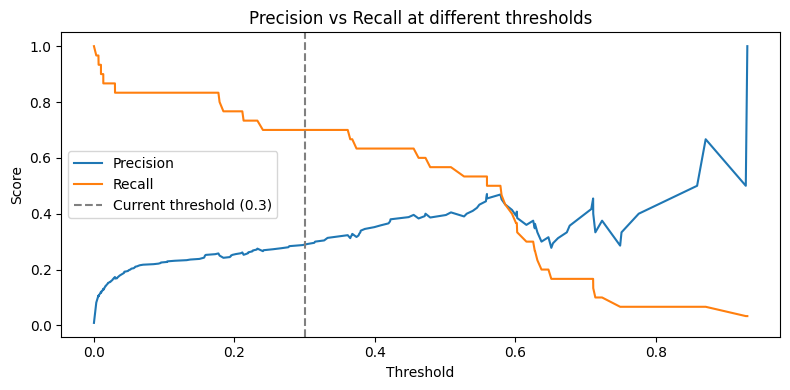

Best threshold for recall (precision>=0.2): 0.05 → recall=0.83, precision=0.20


In [10]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(all_y_true, all_y_prob)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.axvline(x=0.3, color='gray', linestyle='--', label='Current threshold (0.3)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision vs Recall at different thresholds')
plt.tight_layout()
plt.show()

# Also find threshold that maximises recall subject to precision > 0.2
viable = [(t, r, p) for t, r, p in zip(thresholds, recall[:-1], precision[:-1]) if p >= 0.2]
best = max(viable, key=lambda x: x[1])
print(f"Best threshold for recall (precision>=0.2): {best[0]:.2f} → recall={best[1]:.2f}, precision={best[2]:.2f}")

# Try the XGBoost Model

In [11]:
# XGBoost model training and testing
import warnings
warnings.filterwarnings("ignore")
import pickle

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve
)

from xgboost import XGBClassifier

In [12]:
# 1. Define features and target
FEATURE_COLS = [
    "x1",
    "y1",
    "z1",
    "z1_lag1",
    "z1_lag2",
    "z1_lag3",
    "z1_delta1",
    "z1_delta3",
    "z1_roll3_mean",
    "z1_roll3_std",
    "z1_drop_from_lag3",
    "z1_lead_mean5",
    "z1_lead_std3",
    "z1_lead8",
    "z1_is_low"
]

TARGET_COL = "fall_label"

# Keep only required columns
xgb_df = df_model[FEATURE_COLS + [TARGET_COL]].copy()

print("Original shape:", xgb_df.shape)
print("Fall labels before cleaning:", xgb_df[TARGET_COL].sum())

Original shape: (4153, 16)
Fall labels before cleaning: 75


In [13]:
# 2. Check distrivution
print("\nClass distribution:")
print(xgb_df[TARGET_COL].value_counts())


Class distribution:
fall_label
0    4078
1      75
Name: count, dtype: int64


In [14]:
# 3. Split into X and y
X = xgb_df[FEATURE_COLS]
y = xgb_df[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training fall rows:", y_train.sum())
print("Testing fall rows:", y_test.sum())

Training rows: 3322
Testing rows: 831
Training fall rows: 60
Testing fall rows: 15


In [ ]:
# 4. To handle class imbalance (intentionally imperfect cause our model is learning pattern)
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative rows:", negative_count)
print("Positive rows:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative rows: 3262
Positive rows: 60
scale_pos_weight: 54.36666666666667


In [ ]:
# 5. Train XGBoost model
xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, # Balanced weight cause of imbalance
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [ ]:
# 6. Evaluate model
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Best model threshold(Hardcoded based on precision-recall curve analysis)
threshold = 0.35
y_pred = (y_prob >= threshold).astype(int)

print("XGBoost Evaluation at Threshold 0.35")

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Fall", "Fall"],
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("Average Precision:", round(average_precision_score(y_test, y_prob), 4))
print("F1 Macro:", round(f1_score(y_test, y_pred, average="macro"), 4))

XGBoost Evaluation at Threshold 0.35
--------------------------------------------------
              precision    recall  f1-score   support

     No Fall       1.00      1.00      1.00       816
        Fall       0.81      0.87      0.84        15

    accuracy                           0.99       831
   macro avg       0.91      0.93      0.92       831
weighted avg       0.99      0.99      0.99       831

Confusion Matrix:
[[813   3]
 [  2  13]]
ROC-AUC: 0.9931
Average Precision: 0.8775
F1 Macro: 0.9178


# Save the Model

In [18]:
# import pickle

# model_package = {
#     "model": xgb_model,
#     "threshold": 0.35,
#     "feature_cols": FEATURE_COLS,
#     "target_col": TARGET_COL
# }
# with open("xgboost_fall_detection_model.pkl", "wb") as f:
#     pickle.dump(model_package, f)
# print("Model saved successfully as xgboost_fall_detection_model.pkl")

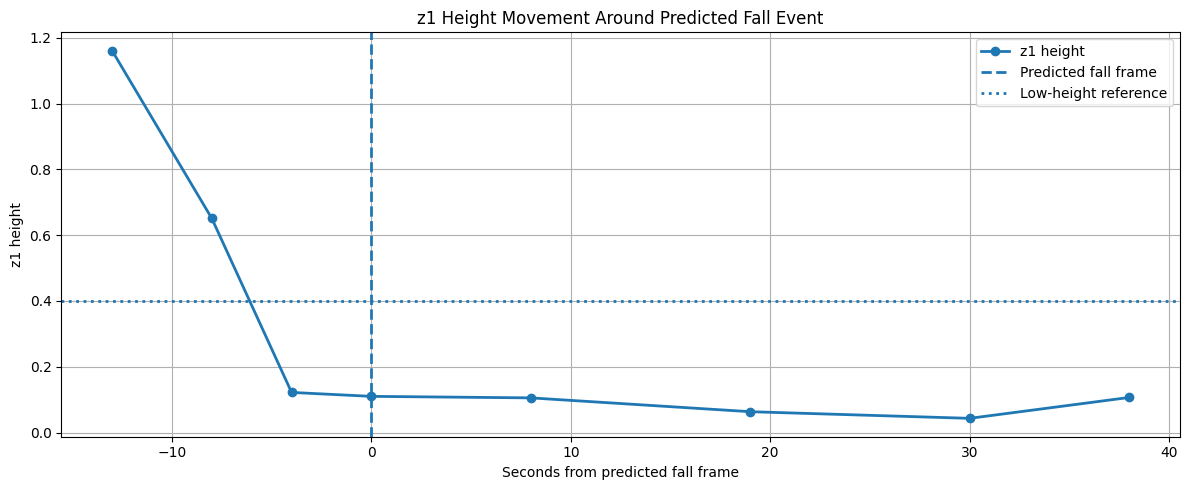

In [ ]:
# Visualization for the best fall label
pred = pd.read_csv("fall_prediction_results.csv")
pred["createTime"] = pd.to_datetime(pred["createTime"])

# Pick a clear detected fall event
event_time = pd.to_datetime("2026-03-14 20:05:13")
event_room = "Kitchen"
event_session = 0

window_start = event_time - pd.Timedelta(seconds=40)
window_end = event_time + pd.Timedelta(seconds=40)

event_window = pred[
    (pred["room"] == event_room) &
    (pred["session_id"] == event_session) &
    (pred["createTime"] >= window_start) &
    (pred["createTime"] <= window_end)
].copy()

event_window["seconds_from_event"] = (
    event_window["createTime"] - event_time
).dt.total_seconds()

event_window = event_window.sort_values("seconds_from_event")

plt.figure(figsize=(12, 5))

plt.plot(
    event_window["seconds_from_event"],
    event_window["z1"],
    marker="o",
    linewidth=2,
    label="z1 height"
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="Predicted fall frame"
)

plt.axhline(
    y=0.4,
    linestyle=":",
    linewidth=2,
    label="Low-height reference"
)

plt.title("z1 Height Movement Around Predicted Fall Event")
plt.xlabel("Seconds from predicted fall frame")
plt.ylabel("z1 height")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# The prediction output shows that the model detected 18 fall-like frames across different room sessions. 
# For the clearest example, the Kitchen event at 2026-03-14 20:05:13 had a z1 height of 0.11 meters and a z1 drop from lag 3 of 1.05 meters, 
# with a fall probability of 0.997.
# This means the radar signal showed a sharp vertical drop followed by a low body position, which is the pattern the XGBoost model learned to classify as a fall.